# Earnings Call Sentiment vs. Stock Price Movement
Angela Liou | Yu-Chien Chen

---
**Research Question:** Can earnings call sentiment predict abnormal stock returns in the days following the call?

###  Notebook Structure
| Section | Description |
|---|---|
| 0 | Install and import packages |
| 1 | Read PDF transcripts and automatically parse dates |
| 2 | Retrieve stock prices using yfinance and calculate CAR for the full event window|
| 3 | FinBERT sentiment analysis |
| 4 | Merge into the main dataset |
| 5 | Train models: Logistic Regression + XGBoost|
| 6 | Evaluate models: AUC, ROC, SHAP|
| 7 | Save files and create backups |

## Section 0: Install and import packages

In [2]:
!pip install pdfplumber yfinance transformers torch xgboost shap scikit-learn pandas numpy matplotlib -q
print('Done!')

Done!


In [3]:
import os, re, time, json, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from datetime import datetime, timedelta

import pdfplumber
import yfinance as yf

import torch
from transformers import pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

print('✅ All libraries imported!')

✅ All libraries imported!


In [4]:
# 30 家公司與產業對應
TICKERS = {
    'Technology':  ['AAPL','MSFT','GOOGL','META','NVDA','AMZN','CRM','INTC'],
    'Financial':   ['JPM','BAC','GS','MS','BLK'],
    'Healthcare':  ['JNJ','UNH','PFE','ABT'],
    'Consumer':    ['WMT','COST','MCD','NKE','SBUX'],
    'Energy':      ['XOM','CVX','COP'],
    'Industrial':  ['CAT','BA','HON'],
    'Telecom':     ['VZ','T'],
}
ALL_TICKERS = [t for group in TICKERS.values() for t in group]
TICKER_TO_SECTOR = {t: s for s, tickers in TICKERS.items() for t in tickers}
print(f'Total companies: {len(ALL_TICKERS)}')

Total companies: 30


---
## Section 1 — 讀取 PDF 逐字稿 & 自動解析日期

**PDF 命名規則（重要！）：**
```
AAPL_2021_Q1.pdf
MSFT_2022_Q2.pdf
MS_Q4_2025.pdf
```
格式：`{TICKER}_{QUARTER}_{YEAR}.pdf`

**日期如何自動抓取：**  
程式會從 PDF 內文裡自動辨識日期，例如：
- `January 15, 2026` → 2026-01-15
- `Q4 2025 Earnings Call January 15, 2026` → 2026-01-15

不需要在檔名裡標日期，程式自動處理。

In [5]:
from google.colab import drive
drive.mount('/content/drive')

# ⬇️ 如果你的資料夾名稱不同，改這行
PDF_FOLDER = '/content/drive/MyDrive/FA/Earnings/'

pdf_files = [f for f in os.listdir(PDF_FOLDER) if f.endswith('.pdf')]
print(f'Found {len(pdf_files)} PDF files:')
for f in sorted(pdf_files):
    print(f'  {f}')

Mounted at /content/drive
Found 300 PDF files:
  AAPL_2023_Q1.pdf
  AAPL_2023_Q2.pdf
  AAPL_2023_Q3.pdf
  AAPL_2023_Q4.pdf
  AAPL_2024_Q1.pdf
  AAPL_2024_Q2.pdf
  AAPL_2024_Q3.pdf
  AAPL_2024_Q4.pdf
  AAPL_2025_Q1.pdf
  AAPL_2025_Q2.pdf
  AAPL_2025_Q3.pdf
  AAPL_2025_Q4.pdf
  ABT_2023_Q1.pdf
  ABT_2023_Q2.pdf
  ABT_2023_Q3.pdf
  ABT_2023_Q4.pdf
  ABT_2024_Q1.pdf
  ABT_2024_Q2.pdf
  ABT_2024_Q3.pdf
  ABT_2024_Q4.pdf
  ABT_2025_Q1.pdf
  ABT_2025_Q2.pdf
  ABT_2025_Q3.pdf
  ABT_2025_Q4.pdf
  AMZN_2023_Q1.pdf
  AMZN_2023_Q2.pdf
  AMZN_2023_Q3.pdf
  AMZN_2023_Q4.pdf
  AMZN_2024_Q1.pdf
  AMZN_2024_Q2.pdf
  AMZN_2024_Q3.pdf
  AMZN_2024_Q4.pdf
  AMZN_2025_Q1.pdf
  AMZN_2025_Q2.pdf
  AMZN_2025_Q3.pdf
  AMZN_2025_Q4.pdf
  BAC_2023_Q1.pdf
  BAC_2023_Q2.pdf
  BAC_2023_Q3.pdf
  BAC_2023_Q4.pdf
  BAC_2024_Q1.pdf
  BAC_2024_Q2.pdf
  BAC_2024_Q3.pdf
  BAC_2024_Q4.pdf
  BAC_2025_Q1.pdf
  BAC_2025_Q2.pdf
  BAC_2025_Q3.pdf
  BAC_2025_Q4.pdf
  BA_Q1_2023.pdf
  BA_Q1_2024.pdf
  BA_Q1_2025.pdf
  BA_Q2_2023.p

In [6]:
# 月份名稱對應表（處理英文月份）
MONTH_MAP = {
    'january':1,'february':2,'march':3,'april':4,
    'may':5,'june':6,'july':7,'august':8,
    'september':9,'october':10,'november':11,'december':12
}

def extract_date_from_text(text):
    """
    從逐字稿文字裡自動找出 earnings call 的日期。
    支援格式：
      - January 15, 2026
      - Jan 15, 2026
      - 2026-01-15
      - January 15, 2026 8:30 AM EST
    """
    text_lower = text.lower()

    # 格式1: Month DD, YYYY (e.g. January 15, 2026)
    pattern1 = r'(january|february|march|april|may|june|july|august|september|october|november|december)\s+(\d{1,2}),?\s+(20\d{2})'
    match = re.search(pattern1, text_lower)
    if match:
        month = MONTH_MAP[match.group(1)]
        day   = int(match.group(2))
        year  = int(match.group(3))
        return f'{year}-{month:02d}-{day:02d}'

    # 格式2: YYYY-MM-DD
    pattern2 = r'(20\d{2})-(\d{2})-(\d{2})'
    match = re.search(pattern2, text)
    if match:
        return match.group(0)

    # 格式3: MM/DD/YYYY
    pattern3 = r'(\d{1,2})/(\d{1,2})/(20\d{2})'
    match = re.search(pattern3, text)
    if match:
        month = int(match.group(1))
        day   = int(match.group(2))
        year  = int(match.group(3))
        return f'{year}-{month:02d}-{day:02d}'

    return None


def extract_ticker_from_filename(filename):
    """
    從檔名解析 ticker。
    支援格式：AAPL_Q1_2021.pdf → AAPL
    """
    name = filename.replace('.pdf', '')
    parts = name.split('_')
    return parts[0].upper() if parts else None


def read_pdf(filepath):
    """
    用 pdfplumber 讀取 PDF，回傳全文字串。
    """
    try:
        with pdfplumber.open(filepath) as pdf:
            pages = []
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    pages.append(text)
        full_text = '\n'.join(pages)
        full_text = re.sub(r'\s+', ' ', full_text).strip()
        return full_text
    except Exception as e:
        print(f'  Error reading PDF: {e}')
        return None


print('✅ PDF functions defined.')

✅ PDF functions defined.


In [7]:
# 讀取所有 PDF
transcripts = []
skipped = []

for fname in sorted(pdf_files):
    fpath = os.path.join(PDF_FOLDER, fname)

    # 從檔名取 ticker
    ticker = extract_ticker_from_filename(fname)
    if not ticker or ticker not in ALL_TICKERS:
        print(f'⚠️  Skipping {fname} — ticker "{ticker}" not in our list')
        skipped.append(fname)
        continue

    # 讀取 PDF 文字
    text = read_pdf(fpath)


    # 從文字自動抓日期（只看前 2000 字，日期通常在開頭）
    date = extract_date_from_text(text[:2000])

    transcripts.append({
        'ticker':   ticker,
        'date':     date,
        'filename': fname,
        'text':     text,
        'sector':   TICKER_TO_SECTOR.get(ticker, 'Unknown')
    })
    print(f'✅ {fname} → {ticker} | {date} | {len(text):,} chars')

print(f'\n📋 Successfully loaded: {len(transcripts)} transcripts')
if skipped:
    print(f'⚠️  Skipped: {skipped}')

✅ AAPL_2023_Q1.pdf → AAPL | 2023-02-02 | 46,651 chars
✅ AAPL_2023_Q2.pdf → AAPL | 2023-05-04 | 47,654 chars
✅ AAPL_2023_Q3.pdf → AAPL | 2023-08-03 | 47,935 chars
✅ AAPL_2023_Q4.pdf → AAPL | 2023-11-02 | 50,465 chars
✅ AAPL_2024_Q1.pdf → AAPL | 2024-02-01 | 45,990 chars
✅ AAPL_2024_Q2.pdf → AAPL | 2024-05-02 | 48,160 chars
✅ AAPL_2024_Q3.pdf → AAPL | 2024-08-01 | 47,319 chars
✅ AAPL_2024_Q4.pdf → AAPL | 2024-10-31 | 47,293 chars
✅ AAPL_2025_Q1.pdf → AAPL | 2025-01-30 | 47,018 chars
✅ AAPL_2025_Q2.pdf → AAPL | 2025-05-01 | 47,865 chars
✅ AAPL_2025_Q3.pdf → AAPL | 2025-07-31 | 47,968 chars
✅ AAPL_2025_Q4.pdf → AAPL | 2025-10-30 | 48,628 chars
✅ ABT_2023_Q1.pdf → ABT | 2023-04-19 | 50,027 chars
✅ ABT_2023_Q2.pdf → ABT | 2023-07-20 | 49,753 chars
✅ ABT_2023_Q3.pdf → ABT | 2023-10-18 | 48,410 chars
✅ ABT_2023_Q4.pdf → ABT | 2024-01-24 | 42,227 chars
✅ ABT_2024_Q1.pdf → ABT | 2024-04-17 | 48,876 chars
✅ ABT_2024_Q2.pdf → ABT | 2024-07-18 | 51,940 chars
✅ ABT_2024_Q3.pdf → ABT | 2024-10-16 | 5

In [8]:
# 檢查日期有沒有抓錯，如果有問題手動修正
df_check = pd.DataFrame([
    {'filename': t['filename'], 'ticker': t['ticker'], 'date': t['date'], 'text_preview': t['text'][:100]}
    for t in transcripts
])
print('Date extraction results:')
print(df_check[['filename','ticker','date']].to_string(index=False))

# ✏️ 如果某個日期抓錯，在這裡手動覆蓋：
# 例如：transcripts[0]['date'] = '2021-01-27'

Date extraction results:
         filename ticker       date
 AAPL_2023_Q1.pdf   AAPL 2023-02-02
 AAPL_2023_Q2.pdf   AAPL 2023-05-04
 AAPL_2023_Q3.pdf   AAPL 2023-08-03
 AAPL_2023_Q4.pdf   AAPL 2023-11-02
 AAPL_2024_Q1.pdf   AAPL 2024-02-01
 AAPL_2024_Q2.pdf   AAPL 2024-05-02
 AAPL_2024_Q3.pdf   AAPL 2024-08-01
 AAPL_2024_Q4.pdf   AAPL 2024-10-31
 AAPL_2025_Q1.pdf   AAPL 2025-01-30
 AAPL_2025_Q2.pdf   AAPL 2025-05-01
 AAPL_2025_Q3.pdf   AAPL 2025-07-31
 AAPL_2025_Q4.pdf   AAPL 2025-10-30
  ABT_2023_Q1.pdf    ABT 2023-04-19
  ABT_2023_Q2.pdf    ABT 2023-07-20
  ABT_2023_Q3.pdf    ABT 2023-10-18
  ABT_2023_Q4.pdf    ABT 2024-01-24
  ABT_2024_Q1.pdf    ABT 2024-04-17
  ABT_2024_Q2.pdf    ABT 2024-07-18
  ABT_2024_Q3.pdf    ABT 2024-10-16
  ABT_2024_Q4.pdf    ABT 2025-01-22
  ABT_2025_Q1.pdf    ABT 2025-04-16
  ABT_2025_Q2.pdf    ABT 2025-07-17
  ABT_2025_Q3.pdf    ABT 2025-10-15
  ABT_2025_Q4.pdf    ABT 2026-01-22
 AMZN_2023_Q1.pdf   AMZN 2023-04-27
 AMZN_2023_Q2.pdf   AMZN 2023-08-03
 AM

---
## Section 2 — yfinance 抓股價 & 計算完整事件窗口

**事件窗口設計：**

```
t-10  t-5        t=0       t+5   t+10  t+20
 |     |        [call]      |     |     |
 ←  Pre-event →        ←     Post-event       →
```

| 窗口 | 用途 |
|---|---|
| t-10 到 t-1 | 市場預期、背景報酬（顯示 event 前走勢）|
| t=0 | Earnings call 當天反應 |
| CAR+1 到 +5 | 即時市場反應 |
| CAR+10 | 主要預測目標（中期反應）|
| CAR+20 | 長期持續效應 |

CAR = 股票報酬 − SPY（大盤）報酬，排除市場整體漲跌影響。

In [9]:
def get_full_event_window(ticker, call_date_str):
    """
    計算 earnings call 前後完整事件窗口的 CAR。

    參數：
        ticker: 股票代碼
        call_date_str: 日期字串 'YYYY-MM-DD'

    回傳：dict，包含 pre-event 和 post-event 的 CAR
    """
    try:
        call_date = pd.Timestamp(call_date_str)

        # 抓足夠長的窗口：event 前 20 天到 event 後 30 天
        start = call_date - timedelta(days=30)
        end   = call_date + timedelta(days=35)

        # 下載股票和大盤（SPY）數據
        stock = yf.download(ticker, start=start, end=end,
                            progress=False, auto_adjust=True)
        spy   = yf.download('SPY',   start=start, end=end,
                            progress=False, auto_adjust=True)

        if stock.empty or spy.empty:
            return None

        # 對齊兩個 DataFrame 的日期
        common_dates = stock.index.intersection(spy.index)
        stock = stock.loc[common_dates, 'Close']
        spy   = spy.loc[common_dates, 'Close']

        # 找 call_date 當天或最近的交易日 index
        base_idx = stock.index.searchsorted(call_date)
        base_idx = min(base_idx, len(stock) - 1)

        base_stock = float(stock.iloc[base_idx])
        base_spy   = float(spy.iloc[base_idx])
        actual_date = str(stock.index[base_idx].date())

        result = {
            'ticker':      ticker,
            'call_date':   call_date_str,
            'actual_date': actual_date,
        }

        # ── Post-event windows ──────────────────────────
        for w in [1, 5, 10, 20]:
            if base_idx + w < len(stock):
                ret_stock = float(stock.iloc[base_idx + w]) / base_stock - 1
                ret_spy   = float(spy.iloc[base_idx + w])   / base_spy   - 1
                result[f'CAR+{w}'] = round(ret_stock - ret_spy, 6)
            else:
                result[f'CAR+{w}'] = None

        # ── Pre-event windows (t=0 當天報酬 vs t-N) ────
        for w in [1, 5, 10]:
            pre_idx = base_idx - w
            if pre_idx >= 0:
                ret_stock = base_stock / float(stock.iloc[pre_idx]) - 1
                ret_spy   = base_spy   / float(spy.iloc[pre_idx])   - 1
                result[f'CAR-{w}'] = round(ret_stock - ret_spy, 6)
            else:
                result[f'CAR-{w}'] = None

        # ── Event day return (當天開盤到收盤) ───────────
        result['event_day_CAR'] = result.get('CAR+1', None)

        return result

    except Exception as e:
        print(f'  Error for {ticker} on {call_date_str}: {e}')
        return None


print('✅ CAR function defined.')

✅ CAR function defined.


In [10]:
# 先用第一筆測試
sample = transcripts[0]
print(f'Testing: {sample["ticker"]} on {sample["date"]}')

result = get_full_event_window(sample['ticker'], sample['date'])
if result:
    print('\n✅ Result:')
    for k, v in result.items():
        if k not in ['ticker', 'call_date']:
            print(f'  {k}: {v}')
else:
    print('❌ Failed')

Testing: AAPL on 2023-02-02

✅ Result:
  actual_date: 2023-02-02
  CAR+1: 0.035029
  CAR+5: 0.023581
  CAR+10: 0.041113
  CAR+20: 0.033129
  CAR-1: 0.022506
  CAR-5: 0.01793
  CAR-10: 0.042549
  event_day_CAR: 0.035029


In [11]:
# 對所有逐字稿計算完整事件窗口
print(f'Calculating CAR for {len(transcripts)} transcripts...\n')

car_results = []
for i, t in enumerate(transcripts):
    result = get_full_event_window(t['ticker'], t['date'])
    if result:
        car_results.append(result)
        print(f'[{i+1}/{len(transcripts)}] ✅ {t["ticker"]} {t["date"]} '
              f'| CAR+5={result.get("CAR+5","N/A"):.3%} '
              f'| CAR+10={result.get("CAR+10","N/A"):.3%}')
    else:
        print(f'[{i+1}/{len(transcripts)}] ❌ {t["ticker"]} {t["date"]} — skipped')

    # 避免 yfinance rate limit
    if (i+1) % 10 == 0:
        time.sleep(2)

df_car = pd.DataFrame(car_results)
print(f'\n✅ CAR calculated: {len(df_car)} rows')
print(df_car.head())

Calculating CAR for 300 transcripts...

[1/300] ✅ AAPL 2023-02-02 | CAR+5=2.358% | CAR+10=4.111%
[2/300] ✅ AAPL 2023-05-04 | CAR+5=3.073% | CAR+10=2.251%
[3/300] ✅ AAPL 2023-08-03 | CAR+5=-6.252% | CAR+10=-6.062%
[4/300] ✅ AAPL 2023-11-02 | CAR+5=2.011% | CAR+10=2.458%
[5/300] ✅ AAPL 2024-02-01 | CAR+5=-1.083% | CAR+10=-4.099%
[6/300] ✅ AAPL 2024-05-02 | CAR+5=3.671% | CAR+10=5.179%
[7/300] ✅ AAPL 2024-08-01 | CAR+5=-0.036% | CAR+10=1.179%
[8/300] ✅ AAPL 2024-10-31 | CAR+5=-4.048% | CAR+10=-3.212%
[9/300] ✅ AAPL 2025-01-30 | CAR+5=-2.051% | CAR+10=0.995%
[10/300] ✅ AAPL 2025-05-01 | CAR+5=-8.601% | CAR+10=-6.475%
[11/300] ✅ AAPL 2025-07-31 | CAR+5=5.976% | CAR+10=10.236%
[12/300] ✅ AAPL 2025-10-30 | CAR+5=0.800% | CAR+10=1.815%
[13/300] ✅ ABT 2023-04-19 | CAR+5=-0.791% | CAR+10=1.006%
[14/300] ✅ ABT 2023-07-20 | CAR+5=0.665% | CAR+10=-3.097%
[15/300] ✅ ABT 2023-10-18 | CAR+5=0.860% | CAR+10=1.179%
[16/300] ✅ ABT 2024-01-24 | CAR+5=2.666% | CAR+10=-0.326%
[17/300] ✅ ABT 2024-04-17 | CAR

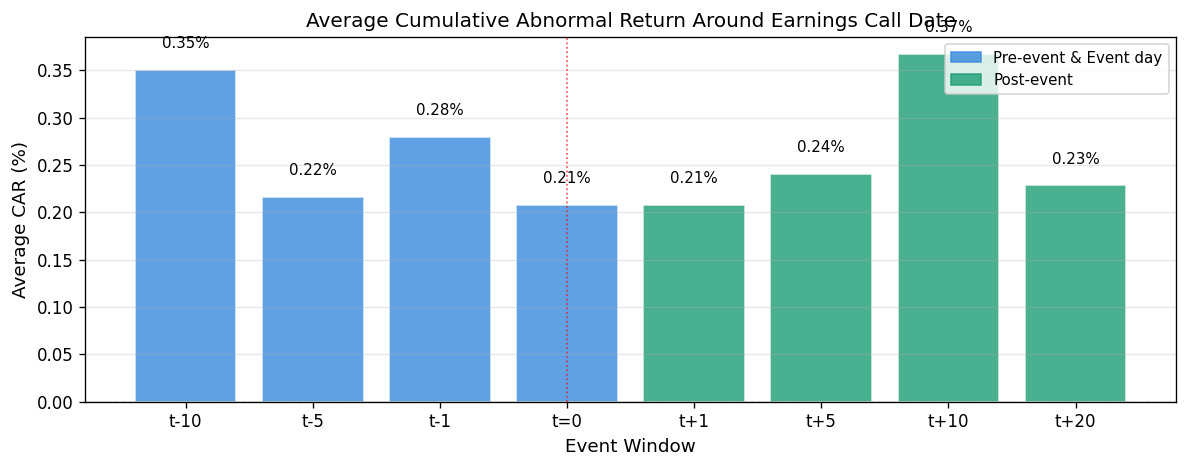

📊 Plot saved!


In [12]:
# 視覺化：平均事件窗口 CAR（所有公司的平均值）
windows = ['CAR-10', 'CAR-5', 'CAR-1', 'event_day_CAR', 'CAR+1', 'CAR+5', 'CAR+10', 'CAR+20']
labels  = ['t-10',  't-5',  't-1',  't=0',           't+1',  't+5',  't+10', 't+20']

# 只取有數據的欄位
available = [w for w in windows if w in df_car.columns]
avail_labels = [labels[windows.index(w)] for w in available]

means = df_car[available].mean()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#378ADD' if 'CAR-' in w or w == 'event_day_CAR' else '#1D9E75'
          for w in available]
bars = ax.bar(avail_labels, means * 100, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(avail_labels.index('t=0') if 't=0' in avail_labels else 3,
           color='red', linewidth=1, linestyle=':', alpha=0.7)
ax.set_xlabel('Event Window', fontsize=11)
ax.set_ylabel('Average CAR (%)', fontsize=11)
ax.set_title('Average Cumulative Abnormal Return Around Earnings Call Date', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# 加數字標籤
for bar, val in zip(bars, means * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#378ADD', alpha=0.8, label='Pre-event & Event day'),
    Patch(color='#1D9E75', alpha=0.8, label='Post-event')
], fontsize=9)

plt.tight_layout()
plt.savefig('/content/event_window_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Plot saved!')

---
## Section 3 — FinBERT 情緒分析

把每篇逐字稿丟進 FinBERT，輸出：
- `pct_positive` / `pct_negative` / `pct_neutral`：各情緒句子佔比
- `sentiment_score`：正面 − 負面（範圍 -1 到 +1）
- `uncertainty_rate`：不確定用詞頻率

> ⏳ GPU 約 1–2 小時，CPU 約 4–6 小時。建議開 GPU（Runtime → Change runtime type → T4 GPU）

In [13]:
print('Loading FinBERT...')
device = 0 if torch.cuda.is_available() else -1
print(f'Using: {"GPU ⚡" if device == 0 else "CPU (slower)"}')

finbert = pipeline(
    'text-classification',
    model='ProsusAI/finbert',
    tokenizer='ProsusAI/finbert',
    device=device,
    top_k=None
)
print('✅ FinBERT loaded!')

Loading FinBERT...
Using: GPU ⚡


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ FinBERT loaded!


In [14]:
UNCERTAINTY_WORDS = [
    'may','might','could','uncertain','uncertainty',
    'challenging','difficult','risk','concern','cautious',
    'headwind','volatile','unclear','potential'
]

def analyze_sentiment(text, max_sentences=150):
    sentences = [s.strip() for s in re.split(r'[.!?]', text) if len(s.strip()) > 20]
    sentences = sentences[:max_sentences]
    if not sentences:
        return None

    results = []
    for i in range(0, len(sentences), 16):
        batch = sentences[i:i+16]
        try:
            results.extend(finbert(batch, truncation=True, max_length=512))
        except Exception:
            continue

    if not results:
        return None

    pos_scores = [max(r, key=lambda x: x['score'] if x['label']=='positive' else 0)['score']
                  if any(x['label']=='positive' for x in r) else 0 for r in results]

    n = len(results)
    pct_pos = sum(1 for r in results if max(r, key=lambda x: x['score'])['label'] == 'positive') / n
    pct_neg = sum(1 for r in results if max(r, key=lambda x: x['score'])['label'] == 'negative') / n
    pct_neu = sum(1 for r in results if max(r, key=lambda x: x['score'])['label'] == 'neutral')  / n

    text_lower = text.lower()
    word_count = len(text.split())
    uncertainty_count = sum(text_lower.count(w) for w in UNCERTAINTY_WORDS)

    return {
        'pct_positive':     round(pct_pos, 4),
        'pct_negative':     round(pct_neg, 4),
        'pct_neutral':      round(pct_neu, 4),
        'sentiment_score':  round(pct_pos - pct_neg, 4),
        'uncertainty_rate': round(uncertainty_count / word_count * 1000, 4),
        'word_count':       word_count,
        'sentence_count':   n
    }


print(f'Analyzing {len(transcripts)} transcripts...')
for i, t in enumerate(transcripts):
    features = analyze_sentiment(t['text'])
    if features:
        t.update(features)
        print(f'[{i+1}/{len(transcripts)}] ✅ {t["ticker"]} {t["date"]} '
              f'| sentiment={features["sentiment_score"]:+.3f} '
              f'| pos={features["pct_positive"]:.1%} '
              f'| neg={features["pct_negative"]:.1%}')

print('\n✅ Sentiment analysis complete!')

Analyzing 300 transcripts...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[1/300] ✅ AAPL 2023-02-02 | sentiment=+0.260 | pos=38.0% | neg=12.0%
[2/300] ✅ AAPL 2023-05-04 | sentiment=+0.293 | pos=40.7% | neg=11.3%
[3/300] ✅ AAPL 2023-08-03 | sentiment=+0.340 | pos=45.3% | neg=11.3%
[4/300] ✅ AAPL 2023-11-02 | sentiment=+0.413 | pos=50.0% | neg=8.7%
[5/300] ✅ AAPL 2024-02-01 | sentiment=+0.407 | pos=48.0% | neg=7.3%
[6/300] ✅ AAPL 2024-05-02 | sentiment=+0.340 | pos=46.0% | neg=12.0%
[7/300] ✅ AAPL 2024-08-01 | sentiment=+0.380 | pos=44.7% | neg=6.7%
[8/300] ✅ AAPL 2024-10-31 | sentiment=+0.460 | pos=49.3% | neg=3.3%
[9/300] ✅ AAPL 2025-01-30 | sentiment=+0.467 | pos=50.0% | neg=3.3%
[10/300] ✅ AAPL 2025-05-01 | sentiment=+0.413 | pos=44.7% | neg=3.3%
[11/300] ✅ AAPL 2025-07-31 | sentiment=+0.413 | pos=46.0% | neg=4.7%
[12/300] ✅ AAPL 2025-10-30 | sentiment=+0.507 | pos=52.7% | neg=2.0%
[13/300] ✅ ABT 2023-04-19 | sentiment=+0.333 | pos=40.7% | neg=7.3%
[14/300] ✅ ABT 2023-07-20 | sentiment=+0.367 | pos=46.0% | neg=9.3%
[15/300] ✅ ABT 2023-10-18 | sentiment=+0.

---
## Section 4 — 合併成主表

In [15]:
SENTIMENT_FEATURES = [
    'pct_positive','pct_negative','pct_neutral',
    'sentiment_score','uncertainty_rate'
]

df_sentiment = pd.DataFrame([
    {**{'ticker': t['ticker'], 'date': t['date'], 'sector': t['sector']},
     **{f: t.get(f) for f in SENTIMENT_FEATURES}}
    for t in transcripts
    if all(t.get(f) is not None for f in SENTIMENT_FEATURES)
])

df_master = df_sentiment.merge(
    df_car, left_on=['ticker','date'], right_on=['ticker','call_date'], how='inner'
)

# 目標變數：CAR+10 > 0 → 漲(1)，否則 → 跌(0)
df_master['label'] = (df_master['CAR+10'] > 0).astype(int)

df_master.to_csv('/content/master_dataset.csv', index=False)

print(f'✅ Master dataset: {df_master.shape[0]} rows × {df_master.shape[1]} cols')
print(f'   Label: {df_master["label"].value_counts().to_dict()} (1=up, 0=down)')
print(f'   Sectors: {df_master["sector"].value_counts().to_dict()}')
df_master.head()

✅ Master dataset: 300 rows × 19 cols
   Label: {1: 157, 0: 143} (1=up, 0=down)
   Sectors: {'Technology': 96, 'Financial': 60, 'Healthcare': 48, 'Industrial': 36, 'Energy': 24, 'Telecom': 24, 'Consumer': 12}


,ticker,date,sector,pct_positive,pct_negative,pct_neutral,sentiment_score,uncertainty_rate,call_date,actual_date,CAR+1,CAR+5,CAR+10,CAR+20,CAR-1,CAR-5,CAR-10,event_day_CAR,label
0,AAPL,2023-02-02,Technology,0.3800,0.1200,0.5000,0.2600,7.1581,2023-02-02,2023-02-02,0.035029,0.023581,0.041113,0.033129,0.022506,0.017930,0.042549,0.035029,1
1,AAPL,2023-05-04,Technology,0.4067,0.1133,0.4800,0.2933,6.7895,2023-05-04,2023-05-04,0.028414,0.030734,0.022511,0.036697,-0.002831,0.002095,0.011228,0.028414,1
2,AAPL,2023-08-03,Technology,0.4533,0.1133,0.4333,0.3400,5.8097,2023-08-03,2023-08-03,-0.043498,-0.062521,-0.060625,-0.019300,-0.004456,-0.002543,-0.002762,-0.043498,0
3,AAPL,2023-11-02,Technology,0.5000,0.0867,0.4133,0.4133,4.7202,2023-11-02,2023-11-02,-0.014304,0.020107,0.024576,0.012612,0.001529,0.019854,0.001872,-0.014304,1
4,AAPL,2024-02-01,Technology,0.4800,0.0733,0.4467,0.4067,5.8176,2024-02-01,2024-02-01,-0.015933,-0.010830,-0.040985,-0.085649,0.000253,-0.040045,-0.036058,-0.015933,0


---
## Section 5 — 訓練模型

In [16]:
FEATURES = ['pct_positive','pct_negative','pct_neutral',
            'sentiment_score','uncertainty_rate']

X = df_master[FEATURES].fillna(0)
y = df_master['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

# Logistic Regression
scaler = StandardScaler()
lr_model = LogisticRegression(random_state=42, max_iter=500)
lr_model.fit(scaler.fit_transform(X_train), y_train)
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(scaler.transform(X_test))[:,1])
print(f'\n📈 Logistic Regression AUC: {lr_auc:.4f}')

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, random_state=42, eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1])
print(f'🚀 XGBoost AUC:             {xgb_auc:.4f}')

Train: 240 | Test: 60

📈 Logistic Regression AUC: 0.4950
🚀 XGBoost AUC:             0.5495


---
## Section 6 — 評估模型

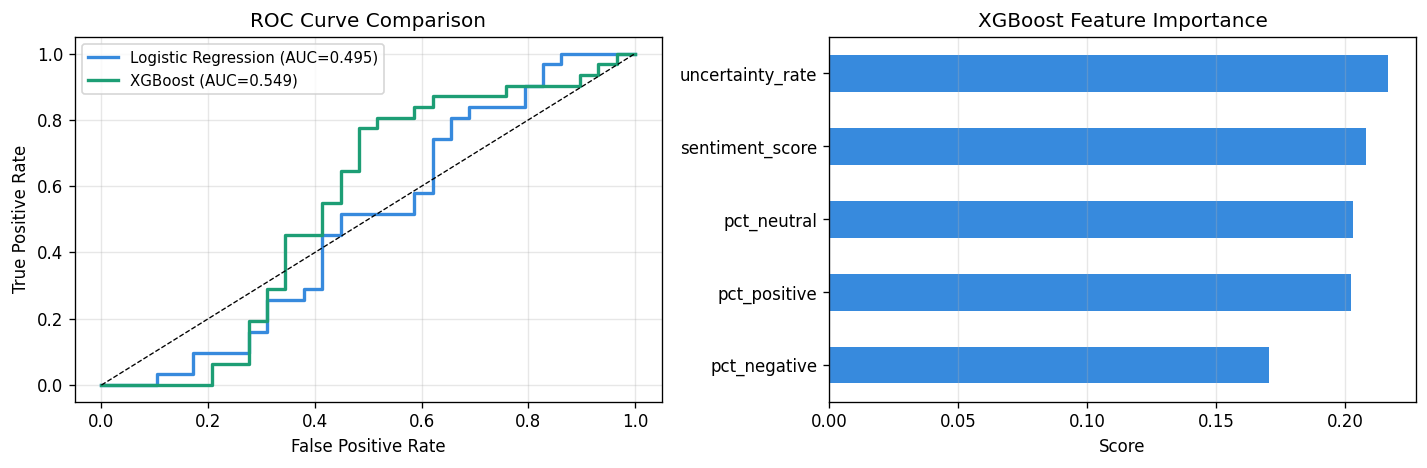

In [17]:
lr_proba  = lr_model.predict_proba(scaler.transform(X_test))[:,1]
xgb_proba = xgb_model.predict_proba(X_test)[:,1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC Curve
ax = axes[0]
for name, proba, color in [
    ('Logistic Regression', lr_proba,  '#378ADD'),
    ('XGBoost',             xgb_proba, '#1D9E75')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Feature Importance
ax = axes[1]
pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values().plot(
    kind='barh', ax=ax, color='#378ADD'
)
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Score')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/content/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

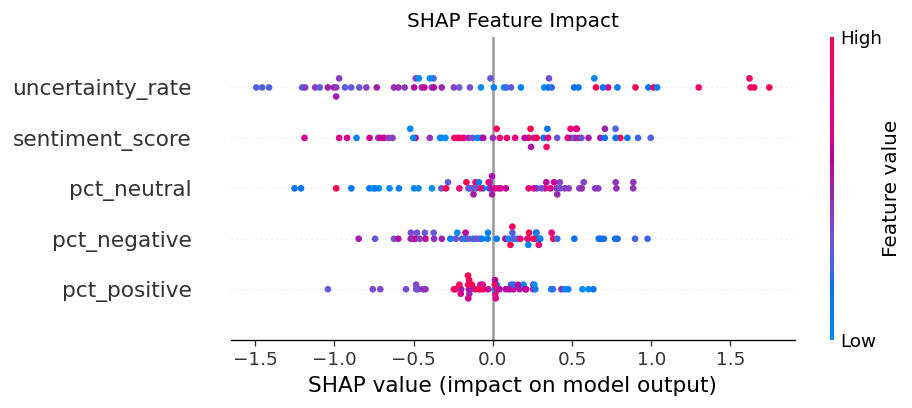

In [18]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(8, 4))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Feature Impact')
plt.tight_layout()
plt.savefig('/content/shap_plot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7 — 存檔備份

In [19]:
import shutil
from google.colab import files

os.makedirs('/content/models', exist_ok=True)

with open('/content/models/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open('/content/models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('/content/models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('/content/models/features.json', 'w') as f:
    json.dump(FEATURES, f)

df_master.to_csv('/content/models/master_dataset.csv', index=False)

# 打包全部下載
shutil.make_archive('/content/final_export', 'zip', '/content/models')
files.download('/content/final_export.zip')

print('✅ Files saved:')
for f in os.listdir('/content/models'):
    size = os.path.getsize(f'/content/models/{f}')
    print(f'  {f} ({size/1024:.1f} KB)')
print('\n🎉 Notebook complete! Next: build Streamlit app.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files saved:
  xgb_model.pkl (133.9 KB)
  scaler.pkl (0.7 KB)
  features.json (0.1 KB)
  master_dataset.csv (45.8 KB)
  lr_model.pkl (0.7 KB)

🎉 Notebook complete! Next: build Streamlit app.
